LANGKAH 7.1 — Setup & Machine-Based Split

### 1. Setup + Load Data + Machine-Based Split
**Tujuan:** Memuat df_ssbs_rul dan menerapkan Machine-Based Split: Train=M-01M-14, Val=M-15M-17, Test=M-18M-20.  
**Input:** data/processed/df_ssbs_rul.parquet  
**Output:** X_train_clf, X_val, X_test, y_train_clf, y_val, y_test  split dasar  
**Catatan:** Alasan Machine-Based (bukan Global Temporal): data run-to-failure menyebabkan WARNING/CRITICAL terkonsentrasi di akhir timeline. Global temporal split akan mengkonsentrasi minority class ke Test set  Train tidak belajar pola degradasi. Machine-based: setiap split punya full run-to-failure cycle.  


  SETUP KONFIRMASI — FASE 7 DATASET SPLITTING

  SRC_PATH           : C:\PORTFOLIO\PROJECTS\PBL\Predictive Maintenance\projects\predictive-maintenance-monorepo\machine_learning\src
  GLOBAL_SEED        : 42
  INPUT_PATH         : df_ssbs_rul.parquet

  Shape df           : (20423, 77)
  FEATURE_COLS       : 69 kolom
  TARGET_CLF         : health_label_encoded
  TARGET_RUL         : rul_days

  Machine IDs (20) : ['M-01', 'M-02', 'M-03', 'M-04', 'M-05', 'M-06', 'M-07', 'M-08', 'M-09', 'M-10', 'M-11', 'M-12', 'M-13', 'M-14', 'M-15', 'M-16', 'M-17', 'M-18', 'M-19', 'M-20']

  Distribusi label global :
    0 (HEALTHY ) :  17,787  (87.09%)
    1 (WARNING ) :   1,247  (6.11%)
    2 (CRITICAL) :   1,389  (6.80%)

  MACHINE-BASED SPLIT

-----------------------------------------------------------------
  [A] SPLIT SUMMARY
-----------------------------------------------------------------

  Split                           Mesin    N Rows   % Total
  ----------------------------------------------

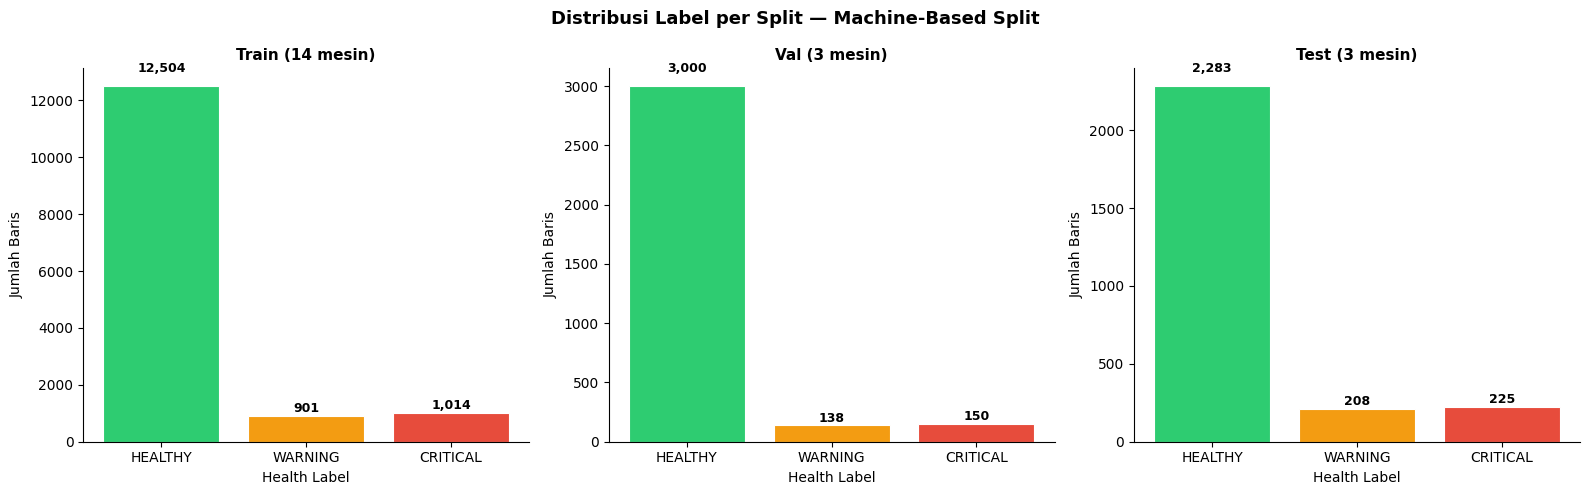


  [OK] Machine-Based Split selesai.
  Train : 14,419 baris | Val : 3,288 baris | Test : 2,716 baris
  [OK] X/y train/val/test untuk CLF & RUL siap untuk Cell 2 (SMOTE).


In [1]:
# ============================================================
# FASE 7 — DATASET SPLITTING
# Cell 1: Setup + Machine-Based Split (Train / Val / Test)
# ============================================================

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ----------------------------------------------------------
# [1] SYS.PATH SETUP
# Notebook: notebooks/fase_7_splitting/
# ML_ROOT  = dua level ke atas
# ----------------------------------------------------------
NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
SRC_PATH     = ML_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# ----------------------------------------------------------
# [2] IMPORT CONFIG
# ----------------------------------------------------------
from config import DATA_PROCESSED_DIR, GLOBAL_SEED, LABEL_MAP

np.random.seed(GLOBAL_SEED)

LABEL_MAP_INV = {v: k for k, v in LABEL_MAP.items()}

# ----------------------------------------------------------
# [3] LOAD DATA
# ----------------------------------------------------------
INPUT_PATH = DATA_PROCESSED_DIR / "df_ssbs_rul.parquet"

df = pd.read_parquet(INPUT_PATH)

df = (
    df
    .sort_values(["machine_id", "timestamp"], ascending=True)
    .reset_index(drop=True)
)

# ----------------------------------------------------------
# [4] DEFINISI KOLOM
# ----------------------------------------------------------
TARGET_CLF  = "health_label_encoded"
TARGET_RUL  = "rul_days"

COLS_EXCLUDE = [
    "timestamp", "machine_id", "health_label",
    "health_label_confirmed", "damage_category",
    "failure", "health_label_encoded", "rul_days",
]
FEATURE_COLS = [c for c in df.columns if c not in COLS_EXCLUDE]

# ----------------------------------------------------------
# [5] KONFIRMASI SETUP
# ----------------------------------------------------------
SEP = "=" * 65
sep = "-" * 65

print(SEP)
print("  SETUP KONFIRMASI — FASE 7 DATASET SPLITTING")
print(SEP)
print(f"\n  SRC_PATH           : {SRC_PATH}")
print(f"  GLOBAL_SEED        : {GLOBAL_SEED}")
print(f"  INPUT_PATH         : {INPUT_PATH.name}")
print(f"\n  Shape df           : {df.shape}")
print(f"  FEATURE_COLS       : {len(FEATURE_COLS)} kolom")
print(f"  TARGET_CLF         : {TARGET_CLF}")
print(f"  TARGET_RUL         : {TARGET_RUL}")

machines = sorted(df["machine_id"].unique().tolist())
print(f"\n  Machine IDs ({len(machines)}) : {machines}")

dist = df[TARGET_CLF].value_counts().sort_index()
print(f"\n  Distribusi label global :")
for code, cnt in dist.items():
    label = LABEL_MAP_INV.get(int(code), "?")
    pct   = cnt / len(df) * 100
    print(f"    {code} ({label:<8}) : {cnt:>7,}  ({pct:.2f}%)")
print(SEP)

# ════════════════════════════════════════════════════════════
# MACHINE-BASED SPLIT
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  MACHINE-BASED SPLIT")
print(SEP)

TRAIN_MACHINES = [
    "M-01", "M-02", "M-03", "M-04", "M-05",
    "M-06", "M-07", "M-08", "M-09", "M-10",
    "M-11", "M-12", "M-13", "M-14",
]
VAL_MACHINES   = ["M-15", "M-16", "M-17"]
TEST_MACHINES  = ["M-18", "M-19", "M-20"]

# ----------------------------------------------------------
# [1] SPLIT BERDASARKAN MACHINE_ID
# ----------------------------------------------------------
df_train = df[df["machine_id"].isin(TRAIN_MACHINES)].copy()
df_val   = df[df["machine_id"].isin(VAL_MACHINES)].copy()
df_test  = df[df["machine_id"].isin(TEST_MACHINES)].copy()

# ----------------------------------------------------------
# [2] PISAHKAN FITUR DAN TARGET
# ----------------------------------------------------------

# --- Model 1: Klasifikasi ---
X_train_clf = df_train[FEATURE_COLS]
y_train_clf = df_train[TARGET_CLF]
X_val_clf   = df_val[FEATURE_COLS]
y_val_clf   = df_val[TARGET_CLF]
X_test_clf  = df_test[FEATURE_COLS]
y_test_clf  = df_test[TARGET_CLF]

# --- Model 2: RUL Regression ---
X_train_rul = df_train[FEATURE_COLS]   # identik dengan X_train_clf
y_train_rul = df_train[TARGET_RUL]
X_val_rul   = df_val[FEATURE_COLS]
y_val_rul   = df_val[TARGET_RUL]
X_test_rul  = df_test[FEATURE_COLS]
y_test_rul  = df_test[TARGET_RUL]

# ════════════════════════════════════════════════════════════
# VALIDASI SPLIT
# ════════════════════════════════════════════════════════════

total_rows = len(df)

# ----------------------------------------------------------
# [1] TABEL SPLIT SUMMARY
# ----------------------------------------------------------
print(f"\n{sep}")
print("  [A] SPLIT SUMMARY")
print(sep)
print()
print(f"  {'Split':<10}  {'Mesin':>25}  {'N Rows':>8}  {'% Total':>8}")
print(f"  {'-'*60}")

splits_info = [
    ("Train", TRAIN_MACHINES, df_train),
    ("Val",   VAL_MACHINES,   df_val),
    ("Test",  TEST_MACHINES,  df_test),
]
for name, machines_list, df_split in splits_info:
    pct = len(df_split) / total_rows * 100
    machine_str = f"{machines_list[0]}..{machines_list[-1]} ({len(machines_list)})"
    print(f"  {name:<10}  {machine_str:>25}  {len(df_split):>8,}  {pct:>7.2f}%")

print(f"  {'-'*60}")
print(f"  {'TOTAL':<10}  {'':>25}  {total_rows:>8,}  {'100.00%':>8}")

# ----------------------------------------------------------
# [2] DISTRIBUSI LABEL PER SPLIT
# ----------------------------------------------------------
print(f"\n{sep}")
print("  [B] DISTRIBUSI LABEL (TARGET_CLF) PER SPLIT")
print(sep)
print()

all_codes = sorted(LABEL_MAP_INV.keys())

for name, _, df_split in splits_info:
    print(f"  {name}:")
    d = df_split[TARGET_CLF].value_counts().sort_index()
    for code in all_codes:
        label = LABEL_MAP_INV.get(code, "?")
        cnt   = int(d.get(code, 0))
        pct   = cnt / len(df_split) * 100 if len(df_split) > 0 else 0
        status = "" if cnt > 0 else " ← [WARN] kelas tidak ada"
        print(f"    {code} ({label:<8}): {cnt:>6,}  ({pct:.2f}%){status}")
    print()

# ----------------------------------------------------------
# [3] STATISTIK RUL PER SPLIT
# ----------------------------------------------------------
print(f"\n{sep}")
print("  [C] STATISTIK RUL (TARGET_RUL) PER SPLIT")
print(sep)
print()
print(f"  {'Split':<8}  {'Min':>8}  {'Max':>8}  {'Mean':>8}  {'Median':>8}")
print(f"  {'-'*46}")
for name, _, df_split in splits_info:
    s = df_split[TARGET_RUL]
    print(f"  {name:<8}  {s.min():>8.2f}  {s.max():>8.2f}  "
          f"{s.mean():>8.2f}  {s.median():>8.2f}")

# ----------------------------------------------------------
# [4] INTEGRITAS — TIDAK ADA OVERLAP MESIN
# ----------------------------------------------------------
print(f"\n{sep}")
print("  [D] CEK INTEGRITAS — TIDAK ADA OVERLAP MESIN")
print(sep)
print()

set_train = set(TRAIN_MACHINES)
set_val   = set(VAL_MACHINES)
set_test  = set(TEST_MACHINES)

overlap_tv = set_train & set_val
overlap_tt = set_train & set_test
overlap_vt = set_val   & set_test

checks = {
    "Train ∩ Val  = ∅" : len(overlap_tv) == 0,
    "Train ∩ Test = ∅" : len(overlap_tt) == 0,
    "Val   ∩ Test = ∅" : len(overlap_vt) == 0,
}
for check_name, passed in checks.items():
    icon = "PASS" if passed else f"FAIL {set_train & set_val}"
    print(f"  [{icon}]  {check_name}")

all_pass = all(checks.values())
print()
if all_pass:
    print("  [OK] ✅ Tidak ada kebocoran mesin antar split.")
else:
    print("  [WARN] ❌ Ada overlap mesin — periksa definisi TRAIN/VAL/TEST_MACHINES.")

# ----------------------------------------------------------
# [5] VISUALISASI DISTRIBUSI LABEL
# ----------------------------------------------------------
COLORS = ["#2ecc71", "#f39c12", "#e74c3c"]
LABEL_NAMES = [LABEL_MAP_INV[c] for c in all_codes]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Distribusi Label per Split — Machine-Based Split",
    fontsize=13, fontweight="bold"
)

plot_splits = [
    ("Train (14 mesin)", df_train),
    ("Val (3 mesin)",    df_val),
    ("Test (3 mesin)",   df_test),
]

for ax, (title, df_split) in zip(axes, plot_splits):
    d    = df_split[TARGET_CLF].value_counts().sort_index()
    vals = [int(d.get(code, 0)) for code in all_codes]

    bars = ax.bar(LABEL_NAMES, vals, color=COLORS,
                  edgecolor="white", linewidth=0.8)

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.03,
            f"{val:,}",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold"
        )

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Health Label", fontsize=10)
    ax.set_ylabel("Jumlah Baris", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\n{SEP}")
print("  [OK] Machine-Based Split selesai.")
print(f"  Train : {len(df_train):,} baris | Val : {len(df_val):,} baris | "
      f"Test : {len(df_test):,} baris")
print("  [OK] X/y train/val/test untuk CLF & RUL siap untuk Cell 2 (SMOTE).")
print(SEP)


LANGKAH 7.2 — SMOTE on X_train Only

### 2. SMOTE pada X_train_clf (CLF Track Only)
**Tujuan:** Menerapkan SMOTE HANYA pada X_train_clf untuk menyeimbangkan kelas minority WARNING dan CRITICAL di training set.  
**Input:** X_train_clf, y_train_clf (dari Cell 1)  Train: 14.419 baris  
**Output:** X_train_clf_smote (20.504×69), y_train_clf_smote  +6.085 sintetis  
**Catatan:** SMOTE target: WARNING 901  4.000 (+3.099 sintetis), CRITICAL 1.014  4.000 (+2.986 sintetis). HEALTHY tidak berubah. X_train_rul TIDAK melalui SMOTE (regression track = natural data). Val & Test = 100% natural data, tanpa sintetis  Zero Data Leakage terkonfirmasi.  

[TARGET] **Dipakai di:** Paper IEEE Section III.D (Imbalance Handling)

  KONFIRMASI ANTI DATA LEAKAGE

  ✅ SMOTE HANYA diaplikasikan pada X_train_clf & y_train_clf
  ✅ X_val, X_test, y_val, y_test TIDAK DISENTUH
  ✅ Ini mencegah Data Leakage temporal

  TARGET_CRITICAL : 4,000 baris (SMOTE)
  K_NEIGHBORS     : 5
  GLOBAL_SEED     : 42

  BAGIAN 1 — DISTRIBUSI y_train_clf SEBELUM SMOTE

  Code    Label         Jumlah         %
  ----------------------------------------
  0       HEALTHY       12,504    86.72%
  1       WARNING          901     6.25%
  2       CRITICAL       1,014     7.03%
  ----------------------------------------
  TOTAL                14,419   100.00%

  Shape X_train_clf : (14419, 69)
  Shape y_train_clf : (14419,)

  BAGIAN 2 — EKSEKUSI SMOTE

  Fitting SMOTE... (mungkin membutuhkan beberapa detik)
  [OK] SMOTE selesai.

  BAGIAN 3 — VALIDASI SETELAH SMOTE

-----------------------------------------------------------------
  [A] DISTRIBUSI y_train_clf_resampled SESUDAH SMOTE
-------------------------------------------------------------

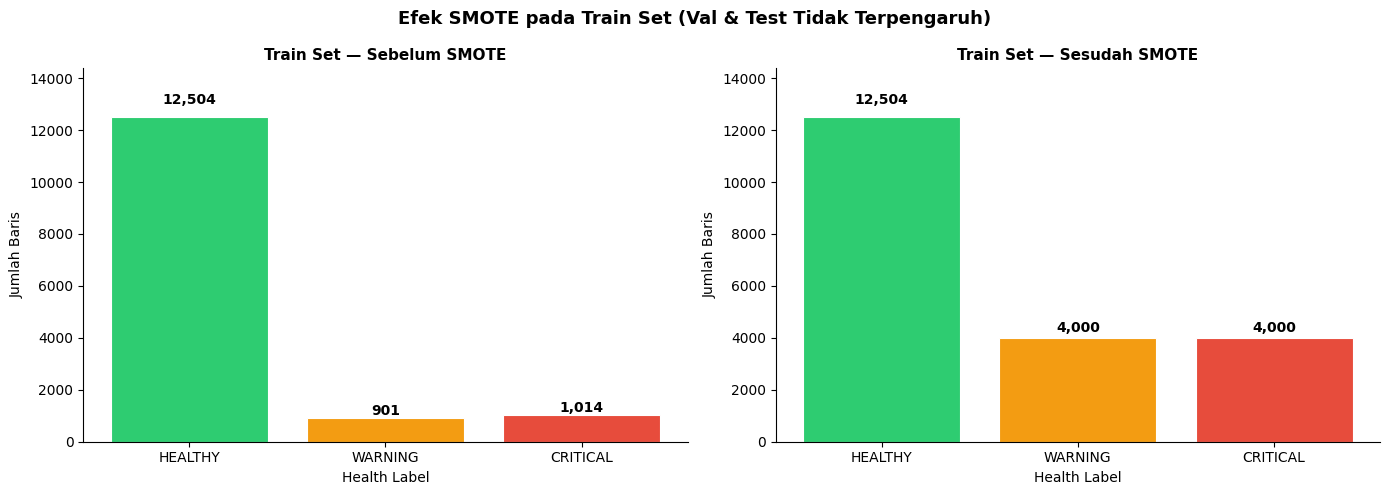


  [OK] SMOTE on X_train_clf selesai.
  [OK] X_train_clf_resampled : (20504, 69)
  [OK] y_train_clf_resampled : (20504,)
  [OK] X_train_rul & y_train_rul tidak diubah (RUL = natural).
  [OK] Siap untuk Cell 3 (Export Split Artifacts).


In [2]:
# ============================================================
# FASE 7 — Cell 2: SMOTE on X_train_clf Only
# Val & Test TIDAK disentuh — mencegah Data Leakage temporal
# ============================================================

import sys
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from pathlib import Path
from imblearn.over_sampling import SMOTE

NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
SRC_PATH     = ML_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from config import GLOBAL_SEED, LABEL_MAP

LABEL_MAP_INV = {v: k for k, v in LABEL_MAP.items()}

SEP = "=" * 65
sep = "-" * 65

# ----------------------------------------------------------
# PARAMETER SMOTE
# ----------------------------------------------------------
TARGET_WARNING  = 4000
TARGET_CRITICAL = 4000
K_NEIGHBORS     = 5

# ----------------------------------------------------------
# KONFIRMASI EKSPLISIT — ANTI LEAKAGE
# ----------------------------------------------------------
print(SEP)
print("  KONFIRMASI ANTI DATA LEAKAGE")
print(SEP)
print()
print("  ✅ SMOTE HANYA diaplikasikan pada X_train_clf & y_train_clf")
print("  ✅ X_val, X_test, y_val, y_test TIDAK DISENTUH")
print("  ✅ Ini mencegah Data Leakage temporal")
print()
print(f"  TARGET_WARNING  : {TARGET_WARNING:,} baris (SMOTE)")
print(f"  TARGET_CRITICAL : {TARGET_CRITICAL:,} baris (SMOTE)")
print(f"  K_NEIGHBORS     : {K_NEIGHBORS}")
print(f"  GLOBAL_SEED     : {GLOBAL_SEED}")

# ════════════════════════════════════════════════════════════
# BAGIAN 1 — DISTRIBUSI SEBELUM SMOTE
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 1 — DISTRIBUSI y_train_clf SEBELUM SMOTE")
print(SEP)
print()

dist_before = dict(sorted(Counter(y_train_clf).items()))
total_before = sum(dist_before.values())

print(f"  {'Code':<6}  {'Label':<10}  {'Jumlah':>8}  {'%':>8}")
print(f"  {'-'*40}")
for code, cnt in dist_before.items():
    label = LABEL_MAP_INV.get(int(code), "?")
    pct   = cnt / total_before * 100
    print(f"  {code:<6}  {label:<10}  {cnt:>8,}  {pct:>7.2f}%")
print(f"  {'-'*40}")
print(f"  {'TOTAL':<17}  {total_before:>8,}  {'100.00%':>8}")

print(f"\n  Shape X_train_clf : {X_train_clf.shape}")
print(f"  Shape y_train_clf : {y_train_clf.shape}")

# ════════════════════════════════════════════════════════════
# BAGIAN 2 — EKSEKUSI SMOTE
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 2 — EKSEKUSI SMOTE")
print(SEP)
print(f"\n  Fitting SMOTE... (mungkin membutuhkan beberapa detik)")

smote = SMOTE(
    sampling_strategy={
        LABEL_MAP["WARNING"]  : TARGET_WARNING,
        LABEL_MAP["CRITICAL"] : TARGET_CRITICAL,
    },
    random_state=GLOBAL_SEED,
    k_neighbors=K_NEIGHBORS,
)

X_train_clf_resampled, y_train_clf_resampled = smote.fit_resample(
    X_train_clf, y_train_clf
)

print(f"  [OK] SMOTE selesai.")

# ════════════════════════════════════════════════════════════
# BAGIAN 3 — VALIDASI SETELAH SMOTE
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 3 — VALIDASI SETELAH SMOTE")
print(SEP)

# [1] Distribusi setelah SMOTE
print(f"\n{sep}")
print("  [A] DISTRIBUSI y_train_clf_resampled SESUDAH SMOTE")
print(sep)
print()

dist_after  = dict(sorted(Counter(y_train_clf_resampled).items()))
total_after = sum(dist_after.values())

print(f"  {'Code':<6}  {'Label':<10}  {'Jumlah':>8}  {'%':>8}")
print(f"  {'-'*40}")
for code, cnt in dist_after.items():
    label    = LABEL_MAP_INV.get(int(code), "?")
    pct      = cnt / total_after * 100
    cnt_prev = dist_before.get(code, 0)
    delta    = cnt - cnt_prev
    delta_str = f"  (+{delta:,} sintetis)" if delta > 0 else ""
    print(f"  {code:<6}  {label:<10}  {cnt:>8,}  {pct:>7.2f}%{delta_str}")
print(f"  {'-'*40}")
print(f"  {'TOTAL':<17}  {total_after:>8,}  {'100.00%':>8}")

# [2] Shape setelah SMOTE
print(f"\n{sep}")
print("  [B] SHAPE SETELAH SMOTE")
print(sep)
print(f"\n  X_train_clf_resampled : {X_train_clf_resampled.shape}")
print(f"  y_train_clf_resampled : {y_train_clf_resampled.shape}")

# [3] Konfirmasi Val dan Test TIDAK berubah
print(f"\n{sep}")
print("  [C] KONFIRMASI VAL & TEST TIDAK BERUBAH")
print(sep)
print()
print(f"  X_val_clf   shape : {X_val_clf.shape}   → [OK] tidak disentuh")
print(f"  y_val_clf   shape : {y_val_clf.shape}    → [OK] tidak disentuh")
print(f"  X_test_clf  shape : {X_test_clf.shape}   → [OK] tidak disentuh")
print(f"  y_test_clf  shape : {y_test_clf.shape}    → [OK] tidak disentuh")

# [4] Total baris sintetis
n_synthetic = len(X_train_clf_resampled) - len(X_train_clf)
print(f"\n{sep}")
print("  [D] BARIS SINTETIS YANG DIBUAT OLEH SMOTE")
print(sep)
print(f"\n  Sebelum SMOTE : {len(X_train_clf):,} baris")
print(f"  Sesudah SMOTE : {len(X_train_clf_resampled):,} baris")
print(f"  Baris sintetis: {n_synthetic:,} baris")
pct_syn = n_synthetic / len(X_train_clf_resampled) * 100
print(f"  % sintetis    : {pct_syn:.2f}% dari total train resampled")

# ════════════════════════════════════════════════════════════
# BAGIAN 4 — VISUALISASI PERBANDINGAN
# ════════════════════════════════════════════════════════════

all_codes   = sorted(LABEL_MAP_INV.keys())
LABEL_NAMES = [LABEL_MAP_INV[c] for c in all_codes]
COLORS      = ["#2ecc71", "#f39c12", "#e74c3c"]

vals_before = [int(dist_before.get(c, 0)) for c in all_codes]
vals_after  = [int(dist_after.get(c, 0))  for c in all_codes]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Efek SMOTE pada Train Set (Val & Test Tidak Terpengaruh)",
    fontsize=13, fontweight="bold"
)

plot_data = [
    ("Train Set — Sebelum SMOTE", vals_before),
    ("Train Set — Sesudah SMOTE", vals_after),
]

for ax, (title, vals) in zip(axes, plot_data):
    bars = ax.bar(LABEL_NAMES, vals, color=COLORS,
                  edgecolor="white", linewidth=0.8)

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.03,
            f"{val:,}",
            ha="center", va="bottom",
            fontsize=10, fontweight="bold"
        )

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Health Label", fontsize=10)
    ax.set_ylabel("Jumlah Baris", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylim(0, max(max(vals_before), max(vals_after)) * 1.15)

plt.tight_layout()
plt.show()

print(f"\n{SEP}")
print("  [OK] SMOTE on X_train_clf selesai.")
print(f"  [OK] X_train_clf_resampled : {X_train_clf_resampled.shape}")
print(f"  [OK] y_train_clf_resampled : {y_train_clf_resampled.shape}")
print("  [OK] X_train_rul & y_train_rul tidak diubah (RUL = natural).")
print("  [OK] Siap untuk Cell 3 (Export Split Artifacts).")
print(SEP)


LANGKAH 7.3 — Export Semua Split Artifacts

### 3. Export 13 Split Artifacts
**Tujuan:** Mengexport semua split artifacts (X, y untuk CLF dan RUL track) ke parquet untuk digunakan di Fase 8.  
**Input:** Semua DataFrame hasil split dan SMOTE  
**Output:** 13 file parquet di data/processed/: X_train_clf, X_train_rul, X_val, X_test, y_train_clf, y_train_rul, y_val_clf, y_val_rul, y_test_clf, y_test_rul, machine_id_val, machine_id_test, df_ssbs_rul  
**Catatan:** Shape final: CLF Train=20.504×69, Val=3.288×69, Test=2.716×69. RUL Train=14.419×69 (no SMOTE), Val=3.288×69, Test=2.716×69.  


In [3]:
# ============================================================
# FASE 7 — Cell 3: Export Semua Split Artifacts
# ============================================================

import json
import numpy as np
import pandas as pd
import sys
from pathlib import Path

NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
SRC_PATH     = ML_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from config import DATA_PROCESSED_DIR, LABEL_MAP

SEP = "=" * 65
sep = "-" * 65

DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(SEP)
print("  EXPORT SPLIT ARTIFACTS — FASE 7")
print(SEP)

# Helper: simpan DataFrame/Series/ndarray ke parquet
def save_parquet(obj, path, columns=None, name=None):
    if isinstance(obj, pd.DataFrame):
        obj.to_parquet(path, index=False)
    elif isinstance(obj, pd.Series):
        obj.to_frame().to_parquet(path, index=False)
    elif isinstance(obj, np.ndarray):
        if obj.ndim == 1:
            pd.Series(obj, name=name).to_frame().to_parquet(path, index=False)
        else:
            pd.DataFrame(obj, columns=columns).to_parquet(path, index=False)
    else:
        raise TypeError(f"Tipe tidak didukung: {type(obj)}")

# ════════════════════════════════════════════════════════════
# BAGIAN 1 — EXPORT MODEL 1 (KLASIFIKASI)
# ════════════════════════════════════════════════════════════

print(f"\n{sep}")
print("  BAGIAN 1 — ARTIFACTS MODEL 1 (KLASIFIKASI / CLF)")
print(sep)
print()

clf_artifacts = [
    # (variabel, path, columns_for_ndarray, name_for_series)
    (X_train_clf_resampled, "X_train_clf.parquet", FEATURE_COLS, None),
    (y_train_clf_resampled, "y_train_clf.parquet", None, "health_label_encoded"),
    (X_val_clf,             "X_val_clf.parquet",   None, None),
    (y_val_clf,             "y_val_clf.parquet",   None, None),
    (X_test_clf,            "X_test_clf.parquet",  None, None),
    (y_test_clf,            "y_test_clf.parquet",  None, None),
]

for obj, fname, cols, sname in clf_artifacts:
    fpath = DATA_PROCESSED_DIR / fname
    save_parquet(obj, fpath, columns=cols, name=sname)
    size_kb = fpath.stat().st_size / 1024
    shape   = (
        obj.shape if hasattr(obj, "shape")
        else (len(obj),)
    )
    print(f"  [OK]  {fname:<35}  shape={str(shape):<20}  {size_kb:.1f} KB")

# ════════════════════════════════════════════════════════════
# BAGIAN 2 — EXPORT MODEL 2 (RUL REGRESSION)
# ════════════════════════════════════════════════════════════

print(f"\n{sep}")
print("  BAGIAN 2 — ARTIFACTS MODEL 2 (RUL REGRESSION)")
print(sep)
print("  Catatan: X_train_rul TIDAK melalui SMOTE")
print("  (regression — distribusi natural dipertahankan)")
print()

rul_artifacts = [
    (X_train_rul, "X_train_rul.parquet", None, None),
    (y_train_rul, "y_train_rul.parquet", None, "rul_days"),
    (X_val_rul,   "X_val_rul.parquet",   None, None),
    (y_val_rul,   "y_val_rul.parquet",   None, "rul_days"),
    (X_test_rul,  "X_test_rul.parquet",  None, None),
    (y_test_rul,  "y_test_rul.parquet",  None, "rul_days"),
]

for obj, fname, cols, sname in rul_artifacts:
    fpath = DATA_PROCESSED_DIR / fname
    save_parquet(obj, fpath, columns=cols, name=sname)
    size_kb = fpath.stat().st_size / 1024
    shape   = (
        obj.shape if hasattr(obj, "shape")
        else (len(obj),)
    )
    print(f"  [OK]  {fname:<35}  shape={str(shape):<20}  {size_kb:.1f} KB")

# ════════════════════════════════════════════════════════════
# BAGIAN 3 — SPLIT METADATA JSON
# ════════════════════════════════════════════════════════════

print(f"\n{sep}")
print("  BAGIAN 3 — SPLIT METADATA JSON")
print(sep)

# Hitung distribusi aktual dari variabel yang tersedia
from collections import Counter

def dist_to_label_dict(counter_or_series):
    """Konversi Counter/value_counts ke dict {LABEL: count}."""
    label_map_inv = {v: k for k, v in LABEL_MAP.items()}
    if isinstance(counter_or_series, pd.Series):
        d = counter_or_series.to_dict()
    else:
        d = dict(counter_or_series)
    return {label_map_inv.get(int(k), str(k)): int(v)
            for k, v in sorted(d.items())}

dist_train_before = dist_to_label_dict(Counter(y_train_clf))
dist_train_after  = dist_to_label_dict(Counter(y_train_clf_resampled))
dist_val          = dist_to_label_dict(y_val_clf.value_counts())
dist_test         = dist_to_label_dict(y_test_clf.value_counts())

def to_shape(obj):
    if hasattr(obj, "shape"):
        return list(obj.shape)
    return [len(obj)]

split_metadata = {
    "split_strategy"     : "Machine-Based Split",
    "total_machines"     : 20,
    "train_machines"     : TRAIN_MACHINES,
    "val_machines"       : VAL_MACHINES,
    "test_machines"      : TEST_MACHINES,
    "smote_applied"      : "X_train_clf only",
    "smote_target"       : {
        "WARNING"  : TARGET_WARNING,
        "CRITICAL" : TARGET_CRITICAL,
    },
    "feature_cols_count" : len(FEATURE_COLS),
    "shapes"             : {
        "X_train_clf_resampled" : to_shape(X_train_clf_resampled),
        "y_train_clf_resampled" : [len(y_train_clf_resampled)],
        "X_val_clf"             : to_shape(X_val_clf),
        "X_test_clf"            : to_shape(X_test_clf),
        "X_train_rul"           : to_shape(X_train_rul),
        "X_val_rul"             : to_shape(X_val_rul),
        "X_test_rul"            : to_shape(X_test_rul),
    },
    "label_distribution" : {
        "train_before_smote" : dist_train_before,
        "train_after_smote"  : dist_train_after,
        "val"                : dist_val,
        "test"               : dist_test,
    },
}

META_PATH = DATA_PROCESSED_DIR / "split_metadata.json"
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(split_metadata, f, indent=2, ensure_ascii=False)

meta_kb = META_PATH.stat().st_size / 1024
print(f"\n  [OK]  split_metadata.json  →  {META_PATH}")
print(f"        Ukuran : {meta_kb:.2f} KB")
print()
print("  Preview isi metadata:")
print(json.dumps(split_metadata, indent=4))

# ════════════════════════════════════════════════════════════
# BAGIAN 4 — KONFIRMASI EXPORT (TABEL LENGKAP)
# ════════════════════════════════════════════════════════════

print(f"\n{SEP}")
print("  BAGIAN 4 — KONFIRMASI SEMUA ARTIFACTS")
print(SEP)
print()

all_files = (
    [f for _, f, _, _ in clf_artifacts] +
    [f for _, f, _, _ in rul_artifacts] +
    ["split_metadata.json"]
)

total_bytes = 0
print(f"  {'Nama File':<40}  {'Ukuran':>10}")
print(f"  {'-'*54}")
for fname in all_files:
    fpath   = DATA_PROCESSED_DIR / fname
    if fpath.exists():
        size_b  = fpath.stat().st_size
        total_bytes += size_b
        size_str = (f"{size_b/1024:.1f} KB" if size_b < 1024**2
                    else f"{size_b/1024**2:.2f} MB")
        print(f"  {fname:<40}  {size_str:>10}")
    else:
        print(f"  {fname:<40}  [TIDAK DITEMUKAN]")

print(f"  {'-'*54}")
print(f"  {'TOTAL':>40}  {total_bytes/1024**2:>9.2f} MB")

print(f"\n{sep}")
print("  CATATAN FINAL")
print(sep)
print()
print("  Fase 7 selesai. Semua artifacts siap untuk Fase 8 Modeling.")
print("  Val dan Test set: 100% natural, tanpa data sintetis.")
print("  SMOTE: hanya pada X_train_clf (Model 1 saja).")
print("  X_train_rul: natural (Model 2 tidak perlu SMOTE - regression).")

print(f"\n{SEP}")
print("  [OK] Export Split Artifacts SELESAI.")
print(f"  [OK] {len(all_files)} file disimpan ke:")
print(f"       {DATA_PROCESSED_DIR}")
print(SEP)


  EXPORT SPLIT ARTIFACTS — FASE 7

-----------------------------------------------------------------
  BAGIAN 1 — ARTIFACTS MODEL 1 (KLASIFIKASI / CLF)
-----------------------------------------------------------------

  [OK]  X_train_clf.parquet                  shape=(20504, 69)           7350.6 KB
  [OK]  y_train_clf.parquet                  shape=(20504,)              1.5 KB
  [OK]  X_val_clf.parquet                    shape=(3288, 69)            894.6 KB
  [OK]  y_val_clf.parquet                    shape=(3288,)               1.3 KB
  [OK]  X_test_clf.parquet                   shape=(2716, 69)            794.1 KB
  [OK]  y_test_clf.parquet                   shape=(2716,)               1.3 KB

-----------------------------------------------------------------
  BAGIAN 2 — ARTIFACTS MODEL 2 (RUL REGRESSION)
-----------------------------------------------------------------
  Catatan: X_train_rul TIDAK melalui SMOTE
  (regression — distribusi natural dipertahankan)

  [OK]  X_train_rul